In [1]:
from google.colab import drive
import os

drive.mount('/content/drive')

DRIVE_CKPT_DIR = '/content/drive/MyDrive/multilingual_mt_checkpoints'
os.makedirs(DRIVE_CKPT_DIR, exist_ok=True)
print(f"Drive checkpoint dir sẵn sàng: {DRIVE_CKPT_DIR}")


Mounted at /content/drive
Drive checkpoint dir sẵn sàng: /content/drive/MyDrive/multilingual_mt_checkpoints


In [2]:
# IMPORTANT: SOME KAGGLE DATA SOURCES ARE PRIVATE
# RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES.
import kagglehub
kagglehub.login()


Kaggle credentials set.
Kaggle credentials successfully validated.


In [3]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.

nyxshade01_multilingual_path = kagglehub.dataset_download('nyxshade01/multilingual')
nyxshade01_multilingual_mt_finetune_path = kagglehub.dataset_download('nyxshade01/multilingual-mt-finetune')

print('Data source import complete.')


100%|██████████| 23.6M/23.6M [00:00<00:00, 76.3MB/s]

Extracting files...


100%|██████████| 732M/732M [00:09<00:00, 78.8MB/s]

Extracting files...


Data source import complete.


# Multilingual MT – Transformer Training (Local)
Chay tren may tinh ca nhan. Du lieu doc tu thu muc du an.

**Chay notebook:** `jupyter notebook notebooks/train_transformer.ipynb`

**Thu muc goc cua du an:** `c:/PKA/Neuron network/Multilingual_MT/`

## Cell 1 – Thiet lap duong dan va thu vien

In [4]:
import os, sys

# Sử dụng đường dẫn từ kagglehub thay vì đường dẫn cứng của Kaggle
DATA_DIR = nyxshade01_multilingual_mt_finetune_path
WORK_DIR = '/content'

os.makedirs(f'{WORK_DIR}/model_assets', exist_ok=True)

if DATA_DIR not in sys.path:
    sys.path.insert(0, DATA_DIR)

# Kiem tra file
checks = {
    'src/models/transformer.py' : f'{DATA_DIR}/src/models/transformer.py',
    'src/data_utils.py'         : f'{DATA_DIR}/src/data_utils.py',
    'tokenizer/tokenizer.json'  : f'{DATA_DIR}/tokenizer/tokenizer.json',
    'data/processed/train.txt'  : f'{DATA_DIR}/data/processed/train.txt',
    'data/processed/val.txt'    : f'{DATA_DIR}/data/processed/val.txt',
}
all_ok = True
for name, path in checks.items():
    ok = os.path.exists(path)
    mb = f'({os.path.getsize(path)/1e6:.1f} MB)' if ok else ''
    print(f'  {"OK  " if ok else "THIEU"} : {name} {mb}')
    if not ok: all_ok = False

print('\nTat ca file san sang!' if all_ok else '\nCANH BAO: Co file bi thieu!')

  OK   : src/models/transformer.py (0.0 MB)
  OK   : src/data_utils.py (0.0 MB)
  OK   : tokenizer/tokenizer.json (1.9 MB)
  OK   : data/processed/train.txt (88.3 MB)
  OK   : data/processed/val.txt (10.4 MB)

Tat ca file san sang!


## Cell 2 – Cau hinh Hyperparameters

In [5]:
import torch

VOCAB_SIZE   = 32_000
# ── Tăng kích thước lên Transformer-Base ──────────────────────────
D_MODEL      = 256
NUM_HEADS    = 8
NUM_LAYERS   = 3
D_FF         = 1024
DROPOUT      = 0.1
PAD_IDX      = 0
BOS_IDX      = 2
EOS_IDX      = 3
MAX_LEN      = 64

NUM_EPOCHS    = 35
BATCH_SIZE    = 64   # giảm xuống vì model lớn hơn, tránh OOM
WARMUP_STEPS  = 4000
LABEL_SMOOTH  = 0.1
GRAD_CLIP     = 1.0
PATIENCE      = 7

TRAIN_FILE     = f'{DATA_DIR}/data/processed/train.txt'
VAL_FILE       = f'{DATA_DIR}/data/processed/val.txt'
TEST_FILE      = f'{DATA_DIR}/data/processed/test.txt'
TOKENIZER_PATH = f'{DATA_DIR}/tokenizer/tokenizer.json'
BEST_MODEL     = f'{WORK_DIR}/model_assets/best_transformer_model.pt'
CKPT_DIR       = f'{WORK_DIR}/model_assets'

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print('='*50)
print(f'  d={D_MODEL} | H={NUM_HEADS} | N={NUM_LAYERS} | batch={BATCH_SIZE}')
print(f'  device={DEVICE}')
print('='*50)

import glob

def find_last_checkpoint(drive_dir):
    files = glob.glob(os.path.join(drive_dir, 'transformer_ep*.pt'))
    if not files:
        return None, 0
    def get_epoch(f):
        base = os.path.basename(f)
        try:
            return int(base.replace('transformer_ep', '').replace('.pt', ''))
        except:
            return 0
    files.sort(key=get_epoch)
    last = files[-1]
    return last, get_epoch(last)

LAST_CKPT_PATH, START_EPOCH = find_last_checkpoint(DRIVE_CKPT_DIR)
print(f"  Resume từ epoch: {START_EPOCH} | file: {LAST_CKPT_PATH}")


  d=256 | H=8 | N=3 | batch=64
  device=cuda
  Resume từ epoch: 17 | file: /content/drive/MyDrive/multilingual_mt_checkpoints/transformer_ep17.pt


## Cell 3 – Nap DataLoader

In [6]:
from src.data_utils import get_dataloaders

print('Dang nap DataLoader...')
train_loader, val_loader, test_loader = get_dataloaders(
    train_file     = TRAIN_FILE,
    val_file       = VAL_FILE,
    test_file      = TEST_FILE,
    tokenizer_path = TOKENIZER_PATH,
    max_len        = MAX_LEN,
    batch_size     = BATCH_SIZE,
    num_workers    = 0,   # Windows: de 0 tranh loi multiprocessing
)

batch = next(iter(train_loader))
print(f'Batch src : {tuple(batch["src"].shape)}  # [B={BATCH_SIZE}, T={MAX_LEN}]')
print(f'Batch tgt : {tuple(batch["tgt"].shape)}')
print(f'Train batches : {len(train_loader)}')
print(f'Val   batches : {len(val_loader)}')

Dang nap DataLoader...
Batch src : (64, 64)  # [B=64, T=64]
Batch tgt : (64, 64)
Train batches : 7969
Val   batches : 938


## Cell 4 – Khoi tao mo hinh Transformer

In [7]:
from src.models.transformer import Transformer
import torch.nn as nn

model = Transformer(
    vocab_size = VOCAB_SIZE,
    d_model    = D_MODEL,
    num_heads  = NUM_HEADS,
    num_layers = NUM_LAYERS,
    d_ff       = D_FF,
    dropout    = DROPOUT,
    pad_idx    = PAD_IDX,
    max_len    = MAX_LEN + 10,
).to(DEVICE)

# Xavier init TRƯỚC khi load (mặc định cho trường hợp train từ đầu)
def init_weights(m):
    count = 0
    for p in m.parameters():
        if p.dim() > 1:
            nn.init.xavier_uniform_(p)
            count += 1
    print(f"  Xavier Uniform: {count} tensor đã khởi tạo.")

PRETRAINED_MODEL = f'{DATA_DIR}/model_assets/best_transformer_model.pt'

if LAST_CKPT_PATH and os.path.exists(LAST_CKPT_PATH):
    print(f"\nResume Drive checkpoint epoch {START_EPOCH}: {LAST_CKPT_PATH}")
    ckpt = torch.load(LAST_CKPT_PATH, map_location=DEVICE)
    model.load_state_dict(ckpt["model_state"])
    print("Đã load checkpoint. Tiếp tục train.")
elif os.path.exists(PRETRAINED_MODEL):
    print(f"\nLoad pretrained: {PRETRAINED_MODEL}")
    ckpt = torch.load(PRETRAINED_MODEL, map_location=DEVICE)
    # Thử load strict=False phòng trường hợp model size thay đổi
    missing, unexpected = model.load_state_dict(ckpt["model_state"], strict=False)
    if missing:
        print(f"  ⚠ Missing keys (sẽ dùng Xavier): {len(missing)}")
        # Chỉ init những layer bị thiếu
        for name, param in model.named_parameters():
            if any(name.startswith(k.split('.')[0]) for k in missing):
                if param.dim() > 1:
                    nn.init.xavier_uniform_(param)
    print("Load pretrained thành công!")
else:
    print("\nKhông tìm thấy checkpoint, train từ đầu.")
    init_weights(model)

total = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"  Tổng tham số: {total:,}")

with torch.no_grad():
    _s = torch.randint(1, VOCAB_SIZE, (2, MAX_LEN)).to(DEVICE)
    _t = torch.randint(1, VOCAB_SIZE, (2, MAX_LEN)).to(DEVICE)
    print(f"  Smoke test: {tuple(model(_s, _t).shape)}")



Resume Drive checkpoint epoch 17: /content/drive/MyDrive/multilingual_mt_checkpoints/transformer_ep17.pt
Đã load checkpoint. Tiếp tục train.
  Tổng tham số: 21,905,408
  Smoke test: (2, 63, 32000)


## Cell 5 – Noam Scheduler
```
lr(step) = D^(-0.5) * min(step^(-0.5), step * warmup^(-1.5))
```
- Giai doan warmup: lr tang tuyen tinh den dinh tai step=warmup_steps
- Giai doan decay : lr giam ty le nghich voi sqrt(step)

In [8]:
import torch.nn as nn

# Dùng Noam Scheduler thật (cần thiết cho Transformer-Base)
class NoamScheduler:
    def __init__(self, optimizer, d_model, warmup_steps, min_lr=1e-5):
        self.optimizer    = optimizer
        self.d_model      = d_model
        self.warmup_steps = warmup_steps
        self.min_lr       = min_lr
        self.step_num     = 0

    def step(self):
        self.step_num += 1
        lr = (self.d_model ** -0.5) * min(
            self.step_num ** -0.5,
            self.step_num * (self.warmup_steps ** -1.5),
        )
        lr = max(lr, self.min_lr)
        for pg in self.optimizer.param_groups:
            pg['lr'] = lr

    def get_lr(self):
        return self.optimizer.param_groups[0]['lr']

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=5e-6,           # LR do Noam quản lý, để 1.0
    betas=(0.9, 0.98),
    eps=1e-9
)

noam = NoamScheduler(optimizer, d_model=D_MODEL, warmup_steps=WARMUP_STEPS, min_lr=1e-5)
criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX, label_smoothing=LABEL_SMOOTH)

print(f"Noam Scheduler | d_model={D_MODEL} | warmup={WARMUP_STEPS} | min_lr=1e-5")


Noam Scheduler | d_model=256 | warmup=4000 | min_lr=1e-5


## Cell 6 – Training Loop (co tien trinh)

In [9]:
import time, shutil
import torch

class DummyScheduler:
    def __init__(self, opt):
        self.optimizer = opt
        self.step_num = 0
    def step(self): pass
    def get_lr(self): return self.optimizer.param_groups[0]['lr']
    def zero_grad(self): self.optimizer.zero_grad()
    def backward_step(self, loss, model, max_norm=1.0):
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm)
        self.optimizer.step()
        self.step_num += 1

noam = DummyScheduler(optimizer)

# Nếu resume từ Drive checkpoint, khôi phục optimizer state
if LAST_CKPT_PATH and os.path.exists(LAST_CKPT_PATH):
    ckpt = torch.load(LAST_CKPT_PATH, map_location=DEVICE)
    try:
        noam.optimizer.load_state_dict(ckpt["optim_state"])
        noam.step_num = ckpt.get("step_num", 0)
        print(f"Đã khôi phục optimizer state tại step {noam.step_num}")
    except Exception as e:
        print(f"Không load được optimizer state: {e}")

LOG_EVERY = 500

def run_epoch(model, loader, criterion, noam, device, training, epoch):
    model.train() if training else model.eval()
    total, n = 0.0, 0
    ctx = torch.enable_grad() if training else torch.no_grad()
    with ctx:
        for batch in loader:
            src = batch["src"].to(device)
            tgt = batch["tgt"].to(device)
            logits = model(src, tgt)
            B, T1, V = logits.shape
            loss = criterion(logits.reshape(B*T1, V), tgt[:,1:].reshape(B*T1))
            total += loss.item(); n += 1
            if training:
                noam.zero_grad()
                noam.backward_step(loss, model, max_norm=1.0)
                if n % LOG_EVERY == 0:
                    print(f"    [Ep{epoch:02d} | batch {n:>5}/{len(loader)} "
                          f"| step {noam.step_num}] "
                          f"loss={total/n:.4f}  lr={noam.get_lr():.6f}")
    return total / n if n else float("inf")

def save_ckpt(model, noam, epoch, val_loss, path):
    torch.save({
        "epoch": epoch, "step_num": noam.step_num,
        "model_state": model.state_dict(),
        "optim_state": noam.optimizer.state_dict(),
        "val_loss": val_loss, "model_config": model.config,
    }, path)

def save_to_drive(local_path, drive_dir):
    """Copy file từ local lên Drive."""
    fname = os.path.basename(local_path)
    drive_path = os.path.join(drive_dir, fname)
    shutil.copy2(local_path, drive_path)
    size_mb = os.path.getsize(drive_path) / 1e6
    print(f"  ✅ Đã lưu Drive: {fname} ({size_mb:.1f} MB)")

best_val, no_improve, history = float("inf"), 0, []

# ── Resume: bắt đầu từ epoch tiếp theo nếu đã có checkpoint ──────
resume_epoch = START_EPOCH + 1

print("=" * 60)
print(f"  TRANSFORMER | epochs {resume_epoch}→{NUM_EPOCHS} | {DEVICE}")
if START_EPOCH > 0:
    print(f"  ↩️  RESUME từ epoch {START_EPOCH}")
print("=" * 60)

for epoch in range(resume_epoch, NUM_EPOCHS + 1):
    t0 = time.time()
    print(f"\n── Epoch [{epoch:02d}/{NUM_EPOCHS}] ──────────────────────────────")

    tr = run_epoch(model, train_loader, criterion, noam, DEVICE, True,  epoch)
    vl = run_epoch(model, val_loader,   criterion, noam, DEVICE, False, epoch)
    dt = time.time() - t0

    ok = vl < best_val
    history.append({"epoch": epoch, "train": tr, "val": vl, "lr": noam.get_lr()})
    print(f"  Train={tr:.4f} | Val={vl:.4f}{'  ← BEST' if ok else ''} | "
          f"lr={noam.get_lr():.6f} | {dt:.0f}s")

    # Lưu checkpoint epoch này (local + Drive)
    ep_path = f"{CKPT_DIR}/transformer_ep{epoch:02d}.pt"
    save_ckpt(model, noam, epoch, vl, ep_path)
    save_to_drive(ep_path, DRIVE_CKPT_DIR)   # ← LƯU LÊN DRIVE

    if ok:
        best_val, no_improve = vl, 0
        save_ckpt(model, noam, epoch, vl, BEST_MODEL)
        shutil.copy2(BEST_MODEL, os.path.join(DRIVE_CKPT_DIR, 'best_transformer_model.pt'))
        print(f"  ⭐ Lưu best model lên Drive.")
    else:
        no_improve += 1
        print(f"  Patience {no_improve}/{PATIENCE}")
        if no_improve >= PATIENCE:
            print("  Early stopping."); break

print(f"\nHOAN TAT | Best Val = {best_val:.4f} | {BEST_MODEL}")


Đã khôi phục optimizer state tại step 95633
  TRANSFORMER | epochs 18→20 | cuda
  ↩️  RESUME từ epoch 17

── Epoch [18/20] ──────────────────────────────
    [Ep18 | batch   500/7969 | step 96133] loss=4.4708  lr=0.000050
    [Ep18 | batch  1000/7969 | step 96633] loss=4.4706  lr=0.000050
    [Ep18 | batch  1500/7969 | step 97133] loss=4.4730  lr=0.000050
    [Ep18 | batch  2000/7969 | step 97633] loss=4.4736  lr=0.000050
    [Ep18 | batch  2500/7969 | step 98133] loss=4.4787  lr=0.000050
    [Ep18 | batch  3000/7969 | step 98633] loss=4.4808  lr=0.000050
    [Ep18 | batch  3500/7969 | step 99133] loss=4.4834  lr=0.000050
    [Ep18 | batch  4000/7969 | step 99633] loss=4.4850  lr=0.000050
    [Ep18 | batch  4500/7969 | step 100133] loss=4.4870  lr=0.000050
    [Ep18 | batch  5000/7969 | step 100633] loss=4.4877  lr=0.000050
    [Ep18 | batch  5500/7969 | step 101133] loss=4.4895  lr=0.000050
    [Ep18 | batch  6000/7969 | step 101633] loss=4.4894  lr=0.000050
    [Ep18 | batch  6500/79

## Cell 7 – Do thi Loss Curve

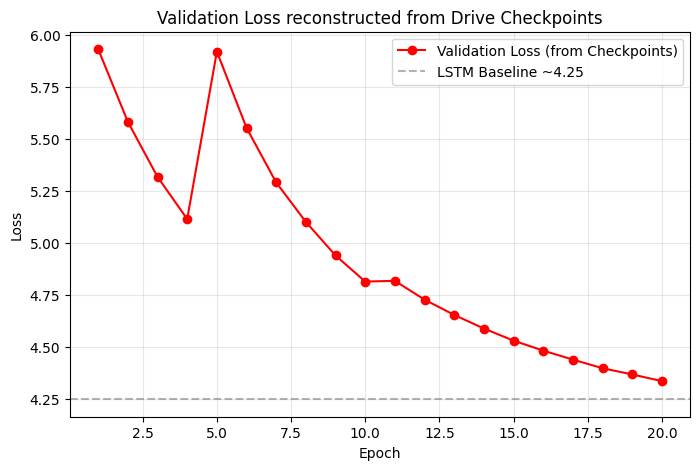

Epoch |   Val Loss
--------------------
    1 |     5.9305
    2 |     5.5819
    3 |     5.3173
    4 |     5.1150
    5 |     5.9191
    6 |     5.5530
    7 |     5.2906
    8 |     5.1013
    9 |     4.9402
   10 |     4.8150
   11 |     4.8183
   12 |     4.7283
   13 |     4.6547
   14 |     4.5895
   15 |     4.5313
   16 |     4.4834
   17 |     4.4404
   18 |     4.3989
   19 |     4.3689
   20 |     4.3371


In [10]:
import glob
import torch
import matplotlib.pyplot as plt

# 1. Quét tất cả các file checkpoint trong thư mục Drive
ckpt_files = glob.glob(os.path.join(DRIVE_CKPT_DIR, 'transformer_ep*.pt'))

if not ckpt_files:
    print("Không tìm thấy checkpoint nào trên Drive để vẽ đồ thị.")
else:
    history_from_ckpts = []

    for f in ckpt_files:
        try:
            checkpoint = torch.load(f, map_location='cpu')
            history_from_ckpts.append({
                'epoch': checkpoint.get('epoch', 0),
                'val': checkpoint.get('val_loss', 0),
                # Một số checkpoint cũ có thể không lưu train_loss hoặc lr
                'train': checkpoint.get('train_loss', 0),
                'lr': checkpoint.get('lr', 0)
            })
        except Exception as e:
            print(f"Lỗi khi đọc file {f}: {e}")

    # 2. Sắp xếp lại theo epoch
    history_from_ckpts.sort(key=lambda x: x['epoch'])

    # 3. Trích xuất dữ liệu để vẽ
    eps_h = [h['epoch'] for h in history_from_ckpts]
    vals_h = [h['val'] for h in history_from_ckpts]

    # 4. Vẽ đồ thị Validation Loss
    plt.figure(figsize=(8, 5))
    plt.plot(eps_h, vals_h, 'r-o', label='Validation Loss (from Checkpoints)')
    plt.axhline(y=4.25, color='gray', linestyle='--', alpha=0.6, label='LSTM Baseline ~4.25')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Validation Loss reconstructed from Drive Checkpoints')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    # Hiển thị bảng dữ liệu
    print(f'{"Epoch":>5} | {"Val Loss":>10}')
    print('-'*20)
    for h in history_from_ckpts:
        print(f'{h["epoch"]:>5} | {h["val"]:>10.4f}')

## Cell 8 – Thu dich cau mau

In [ ]:
from tokenizers import Tokenizer as HFTok

tok = HFTok.from_file(TOKENIZER_PATH)

def translate_beam(src_text: str, beam_size: int = 5, max_out: int = MAX_LEN,
                   length_penalty: float = 0.7) -> str:
    """Beam Search decoding với length penalty."""
    model.eval()
    ids  = tok.encode(src_text).ids[:MAX_LEN]
    ids += [PAD_IDX] * (MAX_LEN - len(ids))
    src_t = torch.tensor([ids], dtype=torch.long).to(DEVICE)

    with torch.no_grad():
        enc_out, src_mask = model._encode(src_t)

    # Khởi tạo beam: mỗi beam = (log_prob, [token_ids])
    beams = [(0.0, [BOS_IDX])]
    completed = []

    for _ in range(max_out):
        candidates = []
        for log_prob, tokens in beams:
            if tokens[-1] == EOS_IDX:
                completed.append((log_prob, tokens))
                continue

            tgt_t = torch.tensor([tokens], dtype=torch.long).to(DEVICE)
            with torch.no_grad():
                dec_out = model._decode(tgt_t, enc_out, src_mask)
                logits  = model.output_projection(dec_out[:, -1, :])  # [1, V]
                log_probs = torch.log_softmax(logits, dim=-1)[0]      # [V]

            # Lấy top beam_size token
            topk_lp, topk_ids = log_probs.topk(beam_size)
            for lp, tid in zip(topk_lp.tolist(), topk_ids.tolist()):
                candidates.append((log_prob + lp, tokens + [tid]))

        # Giữ beam_size beam tốt nhất (chưa kết thúc)
        candidates.sort(key=lambda x: x[0] / (len(x[1]) ** length_penalty), reverse=True)
        beams = [c for c in candidates if c[1][-1] != EOS_IDX][:beam_size]

        # Chuyển beam kết thúc sang completed
        for c in candidates:
            if c[1][-1] == EOS_IDX and c not in completed:
                completed.append(c)

        if not beams:
            break

    # Nếu không có beam hoàn chỉnh, lấy beam tốt nhất đang có
    if not completed:
        completed = beams

    # Chọn câu có score (có tính length penalty) cao nhất
    best = max(completed, key=lambda x: x[0] / (len(x[1]) ** length_penalty))
    out_ids = [t for t in best[1] if t not in (BOS_IDX, EOS_IDX, PAD_IDX)]
    return tok.decode(out_ids, skip_special_tokens=True)


tests = [
    '<2vi> Hello , how are you ?',
    '<2vi> I love machine learning .',
    '<2ja> The weather is beautiful today .',
    '<2zh> Thank you very much .',
    '<2en> Xin chào , bạn có khỏe không ?',
    '<2en> 今日は良い天気ですね。',
]

print('Beam Search (beam=5):\n')
for s in tests:
    print(f'  SRC : {s}')
    print(f'  OUT : {translate_beam(s)}')
    print()


Thu dich sau khi train:

  SRC : <2vi> Hello , how are you ?
  OUT : と一緒に 走了 と一緒に 走了 と一緒に 走了 と一緒に と一緒に と一緒に と一緒に と一緒に と一緒に と一緒に と一緒に と一緒に と一緒に と一緒に と一緒に と一緒に と一緒に と一緒に と一緒に と一緒に と一緒に と一緒に と一緒に と一緒に と一緒に と一緒に と一緒に と一緒に と一緒に と一緒に と一緒に と一緒に と一緒に と一緒に と一緒に と一緒に と一緒に と一緒に と一緒に と一緒に と一緒に と一緒に と一緒に と一緒に と一緒に と一緒に と一緒に と一緒に と一緒に と一緒に と一緒に と一緒に と一緒に と一緒に と一緒に Bow と一緒に と一緒に と一緒に と一緒に と一緒に

  SRC : <2vi> I love machine learning .
  OUT : と一緒に 走了 と一緒に 走了 と一緒に と一緒に と一緒に と一緒に と一緒に と一緒に と一緒に と一緒に と一緒に と一緒に と一緒に と一緒に と一緒に と一緒に と一緒に と一緒に と一緒に と一緒に と一緒に と一緒に と一緒に と一緒に と一緒に と一緒に と一緒に と一緒に と一緒に と一緒に と一緒に と一緒に と一緒に と一緒に と一緒に と一緒に と一緒に と一緒に と一緒に と一緒に と一緒に と一緒に と一緒に と一緒に と一緒に と一緒に と一緒に と一緒に と一緒に と一緒に と一緒に と一緒に と一緒に と一緒に と一緒に と一緒に と一緒に と一緒に と一緒に と一緒に と一緒に と一緒に

  SRC : <2ja> The weather is beautiful today .
  OUT : と一緒に と一緒に と一緒に と一緒に と一緒に と一緒に と一緒に と一緒に と一緒に と一緒に と一緒に と一緒に と一緒に と一緒に と一緒に と一緒に と一緒に と一緒に と一緒に と一緒に と一緒に と一緒に と一緒に と一緒に と一緒に と一緒に と一緒に と一緒に と一緒に と一緒に と一緒に と一緒に と一緒に と一緒に と一緒に と一緒に と一緒に と一緒に と一緒に と一

In [ ]:
# ── Cell cuoi: Copy model ra output de co the download ────────────
import shutil, os

# Kaggle chi cho download file trong /kaggle/working/
# Tat ca da luu vao CKPT_DIR = /kaggle/working/model_assets/ nen ok
print('Cac file da luu:')
for f in sorted(os.listdir(CKPT_DIR)):
    size = os.path.getsize(os.path.join(CKPT_DIR, f)) / 1e6
    print(f'  {f}  ({size:.1f} MB)')

print(f'\nTai ve bang lenh:')
print(f'  kaggle kernels output nyxshade01/multilangual -p model_assets')
